# IncentiveScope — reproducible companion

## Goal
Execute the same fixed-cohort SQL pipeline used by the report. **All included rows are synthetic; no GMX retention claim is made.**

The constructed universe has six cohort addresses. It tests the difference between days 24–30 return, cumulative return, voluntary closing, liquidation and a previously created limit order.

## Setup and assumptions
Run from the repository or notebooks directory after `pip install -e '.[notebook]'`. UTC windows, a fixed denominator, and explicit missing values are shared with the CLI. First-observed labels use the extraction window, not complete protocol history.

In [1]:
import json
from pathlib import Path
from IPython.display import SVG, display
from incentivescope.analyze import analyze
from incentivescope.report import render, figures

root = Path.cwd()
if not (root / 'pyproject.toml').exists():
    root = root.parent
config = json.loads((root / 'configs/demo.json').read_text(encoding='utf-8'))
input_path = root / 'data/sample/trades.csv'
manifest_path = root / 'data/sample/manifest.json'
output_dir = root / 'reports/demo'


## Steps: validate and calculate
`analyze` verifies coverage, completion, SHA-256, uniqueness, normalized fields and timestamps before executing `src/incentivescope/metrics.sql`. Source: the committed synthetic CSV and manifest. This cell does not access a live API.

In [2]:
results = analyze(config, input_path, manifest_path, output_dir)
render(results, output_dir)
print('Synthetic:', results['dataset']['is_synthetic'])
print('Input SHA-256:', results['dataset']['sha256'])
print(json.dumps(results['summary'], indent=2))


Synthetic: True
Input SHA-256: d9263b14cf27032cc82b062c670c02297515430cbd18a3bec85d990bbedf2452
{
  "cohort_size": 6,
  "r30": {
    "n": 3,
    "N": 6,
    "rate": 0.5
  },
  "cumulative30": {
    "n": 4,
    "N": 6,
    "rate": 0.6666666666666666
  },
  "sustained30": {
    "n": 1,
    "N": 6,
    "rate": 0.16666666666666666
  },
  "voluntary30": {
    "n": 4,
    "N": 6,
    "rate": 0.6666666666666666
  },
  "strict_r30": {
    "n": 2,
    "N": 6,
    "rate": 0.3333333333333333
  },
  "r60": {
    "n": 2,
    "N": 6,
    "rate": 0.3333333333333333
  }
}


### Weekly return and entry cohorts
Every post week uses the same fixed campaign cohort denominator. The heatmap columns represent weeks since earning ended, not since each address entered. Counts are printed in each cell. These patterns are constructed software examples.

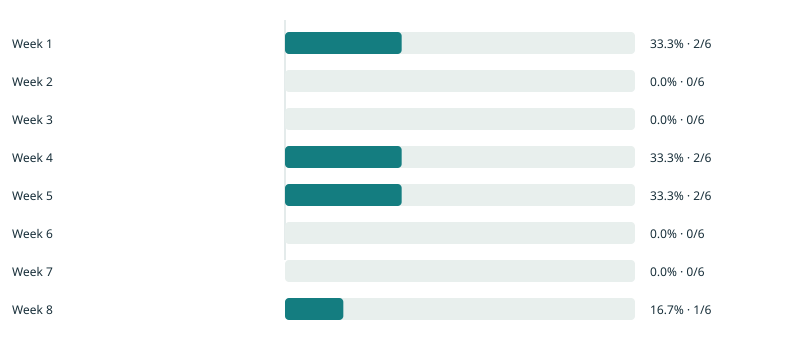

In [3]:
charts = figures(results)
display(SVG(data=charts['weekly']))


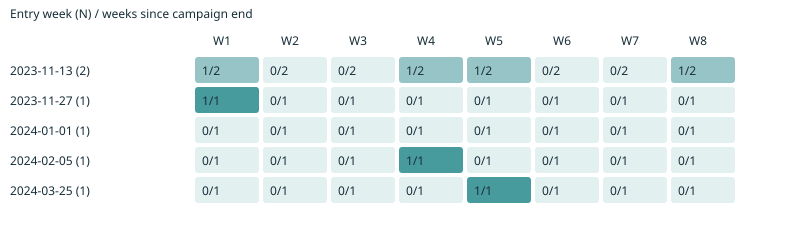

In [4]:
display(SVG(data=charts['heatmap']))


### Definitions change what is counted
Opening/increase return, cumulative return and voluntary trade return answer different questions. Strict return excludes the constructed old limit order. It is withheld if relevant creation times are unknown.

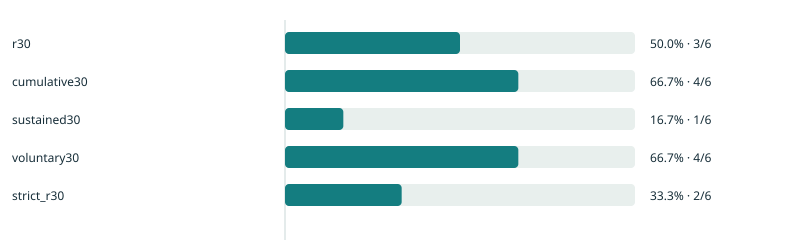

In [5]:
display(SVG(data=charts['robustness']))


## Checks
Hand-calculated expected values for this constructed universe provide a small regression check. They are not external estimates or empirical conclusions.

In [6]:
assert results['summary']['cohort_size'] == 6
assert results['summary']['r30']['n'] == 3
assert results['summary']['cumulative30']['n'] == 4
assert results['summary']['strict_r30']['n'] == 2
assert results['summary']['sustained30']['n'] == 1
print('Expected boundary examples passed.')


Expected boundary examples passed.


## Next steps
Real GMX results require reconciled earning epochs and a complete campaign/follow-up extraction. The committed one-day live receipt only verifies the acquisition path. Address-level rewards and USD fees remain conditional; observational differences do not establish causal acquisition or ROI.